# Model Evaluation 

Up until now we have focused model evaluation on accuracy. While accuracy is useful for classification tasks, it does not always provide a complete picture of a model's performance.

In this notebook we will explore additional metrics suitable for binary classification problems, namely:

- **Receiver Operating Characteristic (ROC) curve**: A graphical representation of the diagnostic ability of a binary classifier across a range of thresholds.

- **Detection Error Tradeoff (DET) curve**: A graphical representation for assessing the trade-offs between different types of classification errors

These metrics provide a deeper insight into the performance characteristics of a binary classifier.

Note that these metrics can be extended to multi-classification problems.

In [54]:
import torch
import torchvision
from torchvision.transforms import v2

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')

import vcpi_util
from importlib import reload
reload (vcpi_util)

<module 'vcpi_util' from 'd:\\vcpi-github\\Deep-Learning-Course-PyTorch\\util\\vcpi_util.py'>

## Auxiliary functions from previous classes

In [55]:
def train_III(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix = 'model'):

    history = {
        'accuracy': [],
        'val_acc': [],
        'val_loss': [],
        'loss': []
    }
    best_val_loss = np.inf

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for index, (inputs, targets) in enumerate(train_loader, 0):
            
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            loss = loss_fn(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            correct += (predicted == targets).sum()

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = (100 * correct / len(train_loader.dataset)).item()

        model.eval()
        with torch.no_grad():
            v_correct = 0
            val_loss = 0.0
            for i,t in val_loader:
                i = i.to(device)
                t = t.to(device)
                o = model(i)
                _,p = torch.max(o,1)
                
                val_loss += loss_fn(o, t).item() * t.size(0)

                v_correct += (p == t).sum()

        val_accuracy = 100 * v_correct / len(val_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; Accuracy: {accuracy:0.4f}; \
              Val Loss: {val_loss:0.6f}; Val Acc: {val_accuracy:0.4f}; \
              Elapsed time: {(stop_time - start_time):0.4f}')
        
        history['accuracy'].append(accuracy)
        history['loss'].append(epoch_loss)
        history['val_acc'].append(val_accuracy)
        history['val_loss'].append(val_loss)
 
        ###### Saving ######
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model':model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
                },
                f'{save_prefix}.pt')

        if early_stopper(val_loss):
            print('Early stopping!')
            break
        
    print('Finished Training')

    return(history)


def evaluate(model, data_loader):

    # sets the model in evaluation mode.
    # although our model does not have layers which behave differently during training and evaluation
    # this is a good practice as the models architecture may change in the future
    model.eval()

    correct = 0
    with torch.no_grad():
        for i, (images, targets) in enumerate(data_loader):
            
            # forward pass, compute the output of the model for the current batch
            outputs = model(images.to(device))

            # "max" returns a namedtuple (values, indices) where values is the maximum 
            # value of each row of the input tensor in the given dimension dim; 
            # indices is the index location of each maximum value found (argmax).
            # the argmax effectively provides the predicted class number        
            _, preds = torch.max(outputs, dim=1)

            correct += (preds.cpu() == targets).sum()

    return (correct / len(data_loader.dataset)).item()


class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta
        self.counter = 0

        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
            
        return False
    


def show_bad_preds(model, data_loader, classes):
    k = 0
    iters = 0

    preds = []
    ground_truth = []
    imgs = torch.Tensor(52, 3, 128,128)

    iterator = iter(data_loader)

    max_iters = len(data_loader)

    model.eval()
    with torch.no_grad():
        while k < 52 and iters < max_iters:

            images, targets = next(iterator)
            #print(images[0].shape)
            logits = model(images.to(device))
            
            #print(predictions[0])
            predictions = torch.nn.functional.softmax(logits, dim=1).cpu().detach().numpy()
            for i in range(len(predictions)):

                if np.argmax(predictions[i]) != targets[i] and k < 52:

                    preds.append(predictions[i])
                    ground_truth.append(int(targets[i]))
                    imgs[k, :, :, :] = images[i]
                    k += 1

            iters += 1

    vcpi_util.plot_predictions(imgs, preds, ground_truth, classes, 13, 4)    


def build_unnormalized_confusion_matrix(model, data_loader, classes=None):

    preds = []
    ground_truth = []

    model.eval()
    with torch.no_grad():

        for images, targets in data_loader:

            logits = model(images.to(device))
            preds_labels = logits.argmax(dim=1).cpu()
            preds.extend(preds_labels.tolist())
            ground_truth.extend(targets.cpu().tolist())

    num_classes = len(data_loader.dataset.classes)
    vcpi_util.show_unnormalized_confusion_matrix(ground_truth, preds, num_classes, classes)    



The model follows the same structure as in the previous classes, but it has two more convolutional blocks, because the images are considerably larger (256x256)

In [22]:

class Conv_III(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        
        # Block 1
        self.conv1 = torch.nn.Conv2d(3, 128, 3)
        self.bn1 = torch.nn.BatchNorm2d(128)
        self.relu1 = torch.nn.ReLU()
        
        self.conv2 = torch.nn.Conv2d(128, 128, 3)
        self.bn2 = torch.nn.BatchNorm2d(128)
        self.relu2 = torch.nn.ReLU()
        
        self.maxpool1 = torch.nn.MaxPool2d(2)

        # Block 2
        self.conv3 = torch.nn.Conv2d(128, 256, 3)
        self.bn3 = torch.nn.BatchNorm2d(256)
        self.relu3 = torch.nn.ReLU()
        
        self.conv4 = torch.nn.Conv2d(256, 256, 3)
        self.bn4 = torch.nn.BatchNorm2d(256)
        self.relu4 = torch.nn.ReLU()
        
        self.maxpool2 = torch.nn.MaxPool2d(2)
    
        # Block 3
        self.conv5 = torch.nn.Conv2d(256, 512, 3)
        self.bn5 = torch.nn.BatchNorm2d(512)
        self.relu5 = torch.nn.ReLU()
        
        self.conv6 = torch.nn.Conv2d(512, 512, 3)
        self.bn6 = torch.nn.BatchNorm2d(512)
        self.relu6 = torch.nn.ReLU()
        
        self.maxpool3 = torch.nn.MaxPool2d(2)

        # Block 4
        self.conv7 = torch.nn.Conv2d(512, 512, 3)
        self.bn7 = torch.nn.BatchNorm2d(512)
        self.relu7 = torch.nn.ReLU()
        
        self.conv8 = torch.nn.Conv2d(512, 512, 3)
        self.bn8 = torch.nn.BatchNorm2d(512)
        self.relu8 = torch.nn.ReLU()
        
        self.maxpool4 = torch.nn.MaxPool2d(2)

        # Dropout (p=0.5 drops 50% of the neurons randomly during training)
        self.dropout = torch.nn.Dropout(p=0.5)

        # Fully Connected (GAP outputs 48 channels as scalars -> 48 inputs)
        self.fc1 = torch.nn.Linear(512, num_classes)
        

    def forward(self, x):    
        
        # input = (bs, 3, 256, 256)
        x = self.conv1(x)       # -> (bs, 128, 254, 254)
        x = self.bn1(x)
        x = self.relu1(x)
        
        x = self.conv2(x)       # -> (bs, 128, 252, 252)
        x = self.bn2(x)
        x = self.relu2(x)
        
        x = self.maxpool1(x)    # -> (bs, 128, 126, 126)
        
        x = self.conv3(x)       # -> (bs, 256, 124, 124)
        x = self.bn3(x)
        x = self.relu3(x)
        
        x = self.conv4(x)       # -> (bs, 256, 122, 122)
        x = self.bn4(x)
        x = self.relu4(x)
        
        x = self.maxpool2(x)    # -> (bs, 256, 61, 61)
        
        x = self.conv5(x)       # -> (bs, 512, 59, 59)
        x = self.bn5(x)
        x = self.relu5(x)
        
        x = self.conv6(x)       # -> (bs, 512, 57, 57)
        x = self.bn6(x)
        x = self.relu6(x)
        
        x = self.maxpool3(x)    # -> (bs, 512, 28, 28)
        
        x = self.conv7(x)       # -> (bs, 512, 26, 26)
        x = self.bn7(x)
        x = self.relu7(x)
        
        x = self.conv8(x)       # -> (bs, 512, 24, 24)
        x = self.bn8(x)
        x = self.relu8(x)
        
        x = self.maxpool4(x)    # -> (bs, 512, 12, 12)
        
        # Apply GAP using torch.mean
        x = torch.mean(x, dim=[2, 3])   # -> (bs, 512)
        
        # Apply Dropout
        x = self.dropout(x)
        
        # Classifier
        x = self.fc1(x)         # -> (bs, 10)

        return x      



## Settings

In [17]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

BASE_PATH = 'd:/vcpi/chest_xRay'

PATH_TRAINING_SET = f'{BASE_PATH}/train'
PATH_TEST_SET = f'{BASE_PATH}/test'

BATCH_SIZE = 8

IMAGE_SIZE = 256

EPOCHS = 10

RUNS = 5

cuda:0


## The dataset

In this notebook we will use the Chest X-Ray [dataset](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)

This dataset is comprised of x-ray images categorized into two classes: normal and pneumonia

In [ ]:
CLASSES = ["Normal", "Pneumonia"]  # index 0 -> Normal, 1 -> Pneumonia

transform = v2.Compose(
    [v2.Resize((IMAGE_SIZE, IMAGE_SIZE)), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)]) 

# No shuffle is required for the test set. 
# It is set to true so that when we later explore somre results we get samples from both classes
test_set = torchvision.datasets.ImageFolder(root=PATH_TEST_SET, transform = transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE, shuffle=True)

train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = transform)
train_sub, val_sub = torch.utils.data.random_split(train_set, [0.8, 0.2])

train_loader = torch.utils.data.DataLoader(train_sub, batch_size = BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_sub, batch_size = BATCH_SIZE)

train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

Batch shape:  torch.Size([8, 3, 256, 256])


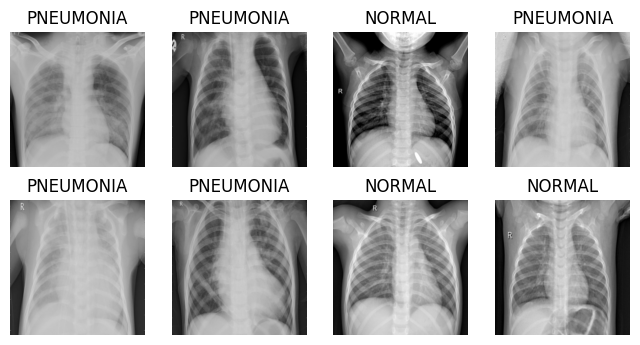

<Figure size 640x480 with 0 Axes>

In [7]:
images, targets = next(iter(train_loader))
print("Batch shape: ", images.shape)
vcpi_util.show_images(2,4, images, targets, train_set.classes) 

## Training

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()

model_Conv = Conv_III(len(train_set.classes))
model_Conv.to(device)

early_stop = Early_Stopping(9)
optimizer = torch.optim.Adam(model_Conv.parameters())
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor = 0.1, patience=3)    


In [19]:
torchinfo.summary(model_Conv, input_size=(BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
Conv_II                                  [8, 2]                    --
├─Conv2d: 1-1                            [8, 128, 254, 254]        3,584
├─BatchNorm2d: 1-2                       [8, 128, 254, 254]        256
├─ReLU: 1-3                              [8, 128, 254, 254]        --
├─Conv2d: 1-4                            [8, 128, 252, 252]        147,584
├─BatchNorm2d: 1-5                       [8, 128, 252, 252]        256
├─ReLU: 1-6                              [8, 128, 252, 252]        --
├─MaxPool2d: 1-7                         [8, 128, 126, 126]        --
├─Conv2d: 1-8                            [8, 256, 124, 124]        295,168
├─BatchNorm2d: 1-9                       [8, 256, 124, 124]        512
├─ReLU: 1-10                             [8, 256, 124, 124]        --
├─Conv2d: 1-11                           [8, 256, 122, 122]        590,080
├─BatchNorm2d: 1-12                      [8, 256, 122, 122]     

In [20]:
history = train_III(model_Conv, train_loader, val_loader, EPOCHS, loss_fn, optimizer, scheduler, early_stop, f'xray')

Epoch: 000; Loss: 0.315095; Accuracy: 86.4264;               Val Loss: 1.361110; Val Acc: 42.5695;               Elapsed time: 165.8753
Epoch: 001; Loss: 0.244069; Accuracy: 90.3374;               Val Loss: 0.452121; Val Acc: 82.0710;               Elapsed time: 126.1286
Epoch: 002; Loss: 0.209010; Accuracy: 91.9287;               Val Loss: 0.137152; Val Acc: 95.2061;               Elapsed time: 117.8702
Epoch: 003; Loss: 0.201066; Accuracy: 92.3888;               Val Loss: 0.134369; Val Acc: 94.8226;               Elapsed time: 119.6848
Epoch: 004; Loss: 0.208875; Accuracy: 91.5069;               Val Loss: 0.108750; Val Acc: 96.2608;               Elapsed time: 116.4440
Epoch: 005; Loss: 0.157925; Accuracy: 93.7883;               Val Loss: 0.400221; Val Acc: 84.9473;               Elapsed time: 115.1880
Epoch: 006; Loss: 0.166909; Accuracy: 93.8842;               Val Loss: 0.183749; Val Acc: 93.0968;               Elapsed time: 116.2686
Epoch: 007; Loss: 0.153082; Accuracy: 94.2485;  

## Evaluating

In [23]:
res = 0
model_Conv = Conv_III(len(train_set.classes))
model_Conv.to(device)

reload = torch.load(f'xray.pt')
model_Conv.load_state_dict(reload['model'])
eval = evaluate(model_Conv, test_loader)
eval_val = evaluate(model_Conv, val_loader)
print(reload['epoch'], eval, eval_val)


7 0.7419871687889099 0.976030707359314


Notice that the validation accuracy (97.6%) is much higher than the test accuracy (74.2%). This indicates that our validation split is optimistic: it does not faithfully represent the difficulty of the test set, and our model (and hyperparameter choices) may have partially overfit the training/validation distribution. 

Show misclassifications

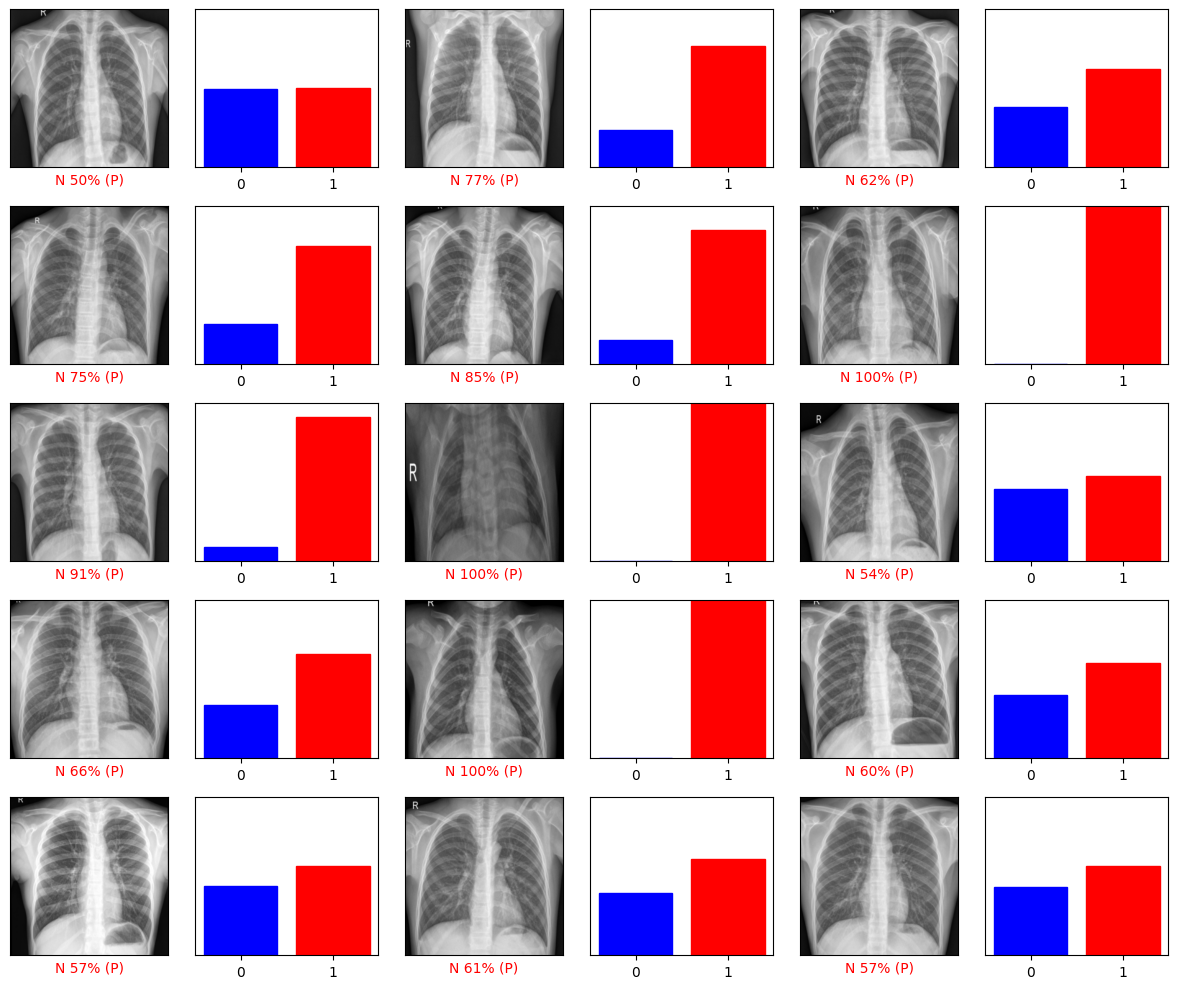

In [ ]:
show_bad_preds(model_Conv, test_loader, ['N', 'P'])   

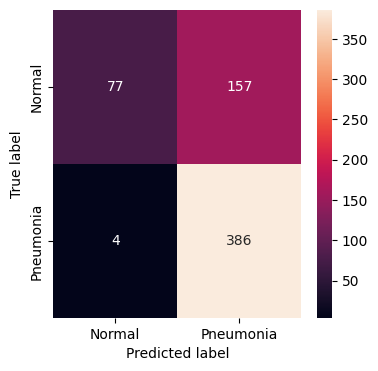

In [57]:
build_unnormalized_confusion_matrix(model_Conv, test_loader, CLASSES)

Confusion Matrix Interpretation from the point of view of the pneumonia class.

|                  | Predicted Normal      | Predicted Pneumonia  |
|------------------|-----------------------|----------------------|
| Actual Normal    | True Negatives (TN)   | False Positives (FP) |
| Actual Pneumonia | False Negatives (FN)  | True Positives (TP)  |




# ROC Curve and AUC

The ROC curve depicts graphically the performance of a model at different classification thresholds. The graph plots two parameters:

True Positive Rate $TPR = \Large \frac{TP }{TP + FN}$ = "how many pneumonia cases we correctly detect"

False Positive Rate $FPR = \Large \frac{FP }{FP + TN}$ = “how often we wrongly call a normal case pneumonia”

In the above Confusion Matrix we have

$TPR = {\Large \frac{386 }{386 + 4}} = 0.987$

$FPR = {\Large \frac{157 }{157 + 77}} = 0.671$

The above values were computed considering a threshold of 0.5. That is, if the model's output for the pneumonia class is above 0.5 then the sample is classified as belonging to the pneumonia class, otherwise, it is classified as normal.

To understand how the model separates the two classes, we now look at the distribution of the pneumonia scores for normal and pneumonia cases. In the plot below, we show the histogram of the model’s output for the pneumonia class, using a logarithmic scale on the vertical axis so that regions with fewer samples remain visible even in the presence of very frequent scores.

In [ ]:
preds = []
ground_truth = []
model_Conv.eval()

for images, targets in test_loader:
    
    logits = model_Conv(images.to(device))
    p = torch.nn.functional.softmax(logits, dim=1).detach().cpu().numpy()
    preds.extend(p)
    ground_truth.extend(targets.numpy())


p = [x[1] for x in preds]

normal = [p[i] for i in range(len(p)) if ground_truth[i] == 0]
pneu = [p[i] for i in range(len(p)) if ground_truth[i] == 1]    


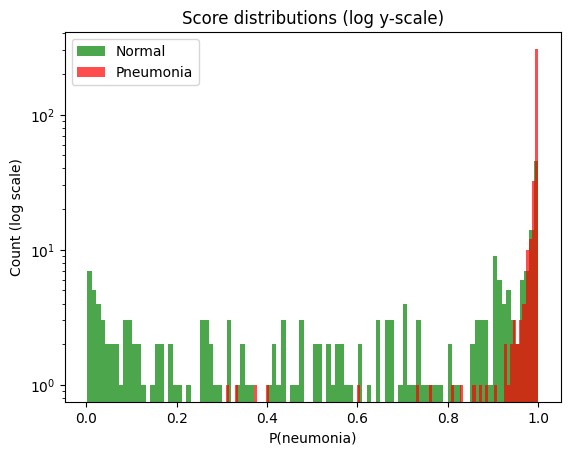

In [60]:
plt.figure(1)
plt.hist(normal, 100, density=0, color="green", alpha=0.7, label="Normal")
plt.hist(pneu,   100, density=0, color="red",   alpha=0.7, label="Pneumonia")
plt.yscale("log")              # <- log scale on vertical axis
plt.xlabel("P(neumonia)")
plt.ylabel("Count (log scale)")
plt.title("Score distributions (log y-scale)")
plt.legend()
plt.show()

The histogram shows that pneumonia scores cluster near 1.0, but there is substantial overlap with the normal scores for thresholds between about 0.3 and 1.0. On this particular test set, we observe that lowering the threshold from 0.5 to 0.3 would eliminate all false negatives (no pneumonia sample would be classified as normal). On the other hand, this would increase the number of false positives (more normal samples classified as pneumonia).

There is a balance to be achieved, and setting the threshold allows us to decide what we value more in this context. One way to frame it is to ask: which is worse, sending someone with pneumonia home because the result appears normal, or telling a healthy person that he/she has  pneumonia?

This reasoning, however, only makes sense if the dataset as a whole (train/val/test) is representative of the real clinical distribution, which we have already concluded it is not. Therefore, the threshold that looks best on this dataset may not transfer directly to real‑world deployment.

It is possible to achieve higher accuracy levels if the threshold is set at the right value. However, this only works if the dataset we use to fine tune the threshold is truly representative of the underlying distribution of the problem.

In [62]:
from sklearn.metrics import accuracy_score
from sklearn import preprocessing

bin = [0 if x < 0.92 else 1  for x in p]

accuracy_score(ground_truth, bin)

0.8413461538461539

### ROC curve for the pneumonia class

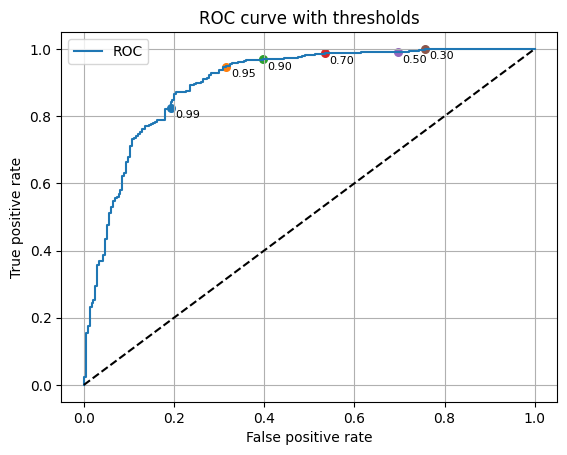

In [65]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import numpy as np

fpr, tpr, thresholds = roc_curve(ground_truth, p)

plt.figure()
plt.plot(fpr, tpr, label="ROC")
plt.plot([0, 1], [0, 1], "k--")

# choose some thresholds to label
for thr in [0.99, 0.95, 0.9, 0.7, 0.5, 0.3]:
    # find nearest point on ROC
    idx = np.argmin(np.abs(thresholds - thr))
    plt.scatter(fpr[idx], tpr[idx], s=30)
    plt.text(
        fpr[idx] + 0.01, tpr[idx] - 0.03,
        f"{thr:.2f}",
        fontsize=8
    )

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve with thresholds")
plt.grid(True)
plt.legend()
plt.show()

The ROC curve shows how the true positive rate and false positive rate change as we sweep the decision threshold from 1.0 (bottom‑left) to 0.0 (top‑right). The ideal classifier would achieve a point in the top‑left corner of the plot (TPR = 1, FPR = 0), but in realistic problems this is not achievable except for very simple problems or toy datasets. Instead, we must choose a threshold value that fits the problem. For instance, in this case, does it make sense to prioritize catching as many patients with pneumonia, or to avoid raising false alarms in healthy patients?

The ROC curve is commonly summarized by the area under the curve (AUC), a single number between 0 and 1 that measures the model’s overall ability to discriminate between normal and pneumonia cases across all possible thresholds.


In [66]:
from sklearn.metrics import auc
auc_model = auc(fpr, tpr)

print('AUC = ', auc_model)

AUC =  0.8993973263204031


# Det Curve

While the ROC curve plots true positive rate (TPR) versus false positive rate (FPR), the DET curve replaces TPR by the false negative rate (FNR), which can make the trade‑off between the two error types more visually apparent.

In a Detection Error Tradeoff (DET) curve, the false positive rate (FPR) and false negative rate (FNR, or miss rate) are plotted against each other to show how reducing one type of error typically increases the other as we vary the decision threshold.

False Positive Rate: $FPR = \Large \frac{FP }{FP + TN}$

False Negative Rate (miss rate): $FNR = \Large \frac{FN }{FN + TP}$

Mathematically, this DET curve contains the same information as the ROC curve as $FNR = 1−TPR$,  but plotting error vs error can help emphasize the trade‑off between the two types of mistakes.

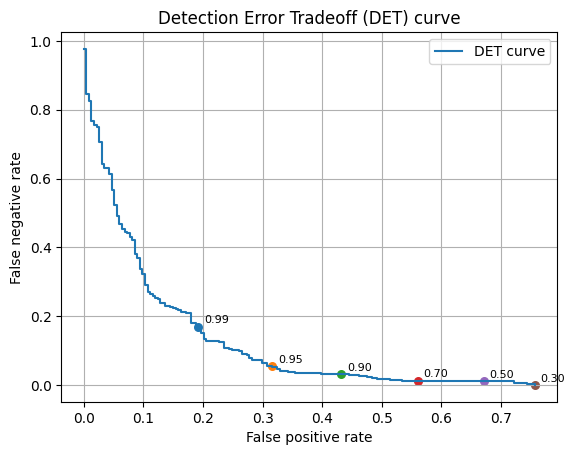

In [69]:
from sklearn.metrics import det_curve
import matplotlib.pyplot as plt
import numpy as np

fpr, fnr, thresholds = det_curve(ground_truth, p)

plt.figure()
plt.plot(fpr, fnr, label="DET curve")
plt.xlabel("False positive rate")
plt.ylabel("False negative rate")
plt.title("Detection Error Tradeoff (DET) curve")
plt.grid(True)

# choose some thresholds to annotate
for thr in [0.99, 0.95, 0.9, 0.7, 0.5, 0.3]:
    idx = np.argmin(np.abs(thresholds - thr))
    plt.scatter(fpr[idx], fnr[idx], s=30)
    plt.text(
        fpr[idx] + 0.01,
        fnr[idx] + 0.01,
        f"{thr:.2f}",
        fontsize=8
    )

plt.legend()
plt.show()

In [70]:
mini = np.min([p[i] for i in range(len(p)) if ground_truth[i] == 1])
print(min)

<built-in function min>
